## STEP 1: Import relevant libraries

In [232]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

## STEP 2: Load the dataset

In [233]:
sales_df = pd.read_excel("/Users/luxdevhq/Desktop/Data Science CH07/EDA/data/raw/dirty_supplement_sales_data_2020.xlsx")
sales_df.head()

,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,$10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,-1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,-1.0,15,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,$10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,$10.99,50.0,0.000,Mobile App,new york


## STEP 3: Inspecting Data. 
_View the top and last rows_. 

In [234]:
# Viewing the top 5 rows
print(f"Top 5 Rows:  {display(sales_df.head())}")

# Viewing the last 5 rows 
print(f"Last 5 Rows: {display(sales_df.tail())}")


,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,$10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,-1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,-1.0,15,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,$10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,$10.99,50.0,0.000,Mobile App,new york


Top 5 Rows:  None


,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
3095,2020-09-16,Immunity Boosters,SuperV!ta,10.0,2.0,NaN,25.0,NaN,In-Store,Chicago
3096,2020-08-12,Vitamins,DreamRest,25.0,0.0,NaN,25.0,NaN,onlien,New York
3097,2020-10-21,Immunity Boosters,SuperV!ta,NaN,-1.0,$10.99,25.0,0.0,Mobile App,Chi-Town
3098,2020-02-19,Weight Loss,SuperVita,NaN,NaN,NaN,NaN,NaN,Instore,Chicago
3099,2020-08-26,Protein,PowerFuel,NaN,0.0,15,0.0,0.0,Mobile App,Phoenix


Last 5 Rows: None


__Inspecting the shape of the datset__

In [235]:
sales_df.shape

(3100, 10)

__Check the summary information about the dataset__

In [236]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3100 non-null   str    
 1   Product Category  3100 non-null   str    
 2   Product Name      3100 non-null   str    
 3   Units Sold        1551 non-null   float64
 4   Units Returned    2495 non-null   float64
 5   Price             2457 non-null   object 
 6   Discount (%)      2651 non-null   float64
 7   Revenue           2457 non-null   float64
 8   Platform          3100 non-null   str    
 9   Location          3100 non-null   str    
dtypes: float64(4), object(1), str(5)
memory usage: 242.3+ KB


In [237]:
# Checking the data types 
sales_df.dtypes

Date                    str
Product Category        str
Product Name            str
Units Sold          float64
Units Returned      float64
Price                object
Discount (%)        float64
Revenue             float64
Platform                str
Location                str
dtype: object

__Inspecting summary statistics__  
_i). Numerical columns_

In [238]:
sales_df.describe().T # alternatively you can use the .transponse()

,count,mean,std,min,25%,50%,75%,max
Units Sold,1551.0,24.514507,14.398598,1.0,11.5,24.0,37.0,50.0
Units Returned,2495.0,0.478557,1.120023,-1.0,-1.0,0.0,1.0,2.0
Discount (%),2651.0,35.403621,35.162792,0.0,10.0,25.0,50.0,105.0
Revenue,2457.0,101.290307,159.300390,-37.5,0.0,0.0,180.0,735.0


_ii). Categorical features_

In [239]:
sales_df.describe(include='str').T  # For those using older versions of pandas use include='object'

,count,unique,top,freq
Date,3100,104,2020-05-20,68
Product Category,3100,6,Protein,555
Product Name,3100,8,Slim F@st,409
Platform,3100,6,Instore,537
Location,3100,8,L.A.,421


__Inspecting columns in the dataset__

In [240]:
sales_df.columns

Index(['Date', 'Product Category', 'Product Name', 'Units Sold',
       'Units Returned', 'Price', 'Discount (%)', 'Revenue', 'Platform',
       'Location'],
      dtype='str')

__Inspecting missing values__

In [241]:
sales_df.isnull().sum()

Date                   0
Product Category       0
Product Name           0
Units Sold          1549
Units Returned       605
Price                643
Discount (%)         449
Revenue              643
Platform               0
Location               0
dtype: int64

## STEP 4: Data Cleaning. 
### 4.1 Standardizing column names.  
_Why Standardization Matters_  
- Prevents code errors: Languages like python can fail if column names contain hidden spaces,trailing whitespaces, special characters, double spaces. e.g " Column1", "Column  Name".  
- Simplifies merging: Joining datasets requires matching key columns; different names e.g(StudentID vs Student ID vs studentid) pd.merge(dataset1, dataset2, datset3, on="id"). 
- Improves readability.    

_Common practices in standardization_  
- Use of lowercase letters. 
- Replace spaces with underscores.  

In [242]:
# # Standardize the column names
# # 1. Stripping any preceding or trailing spaces. 
# sales_df.columns = sales_df.columns.str.strip() # Strip removes any trailing or preceding spaces " Column1" or "Column1 " or " Column1 "  

# # 2. Set the column names to lowercase   
# sales_df.columns = sales_df.columns.str.lower() 

# # 3. Remove any spaces between words and replace with underscores. 
# sales_df.columns = sales_df.columns.str.replace(" ", "_")

# # Print the columns
# sales_df.columns

In [243]:
# # Remove the percentage sign from the discount column. 
# sales_df = sales_df.rename(columns={"discount_(%)" : "discount_percentage"})

In [244]:
sales_df.columns = sales_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('_(%)', '_percentage', regex=False)

In [245]:
sales_df.columns

Index(['date', 'product_category', 'product_name', 'units_sold',
       'units_returned', 'price', 'discount_percentage', 'revenue', 'platform',
       'location'],
      dtype='str')

__Note:__ INstead of writing individual code you can use:  
```python 
sales_df.columns = sales_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('_(%)', '_perecentage', regex=False)
```  
`regex=False`  
- Regex is a short form for Regualr Expression, is a sequence of special characters that form a search pattern. 

### Standardising data types.  
Common data types:  
- Text/Object/Strings  
- Integer. 
- Float(Decimal)
- Date/Datetime 
- Boolean. 

__Common problems:__  
- Date stored as text  
- Numbers stored as text.  
- Currency values stored with symbols ($30)  
- percentages stored as text 


_Date Column_

In [246]:
sales_df.isnull().sum()

date                      0
product_category          0
product_name              0
units_sold             1549
units_returned          605
price                   643
discount_percentage     449
revenue                 643
platform                  0
location                  0
dtype: int64

In [247]:
# Converting the date column to datetype
sales_df["date"] = pd.to_datetime(sales_df["date"], format='mixed', errors='coerce')  

# US Date Format mm/dd/yyyy 
# sales_df["date"] = sales_df["date"].dt.strftime('%m/%d/%Y')

_Price_

In [248]:
sales_df["price"].unique()

array(['$10.99', nan, 15, '12.50 USD', 9.99], dtype=object)

In [249]:
# Drop the $ symbol and the USD str. 
sales_df['price'] = sales_df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Convert the price column to numeric datatype
sales_df["price"] = pd.to_numeric(sales_df["price"], errors='coerce')

- `.astype(str)`: Converts the entire column into text(strings) so that string specific methods can be used.  
- `.str.replace(...)`: Searches the text for specif patterns and replaces them.  
- `r'[^0-9.]'`: This is a regular expression (regex). The ^ inside the brackets means "NOT". It translates to "Find anything that is not a number (0-9) and not a decimal (.)". 

__NOTE:__ You alternatively use:  
```python
sales_df['price']= pd.to_numeric(sales_df['price'].astype(str).str.replace(r'[^0-9.]','',regex=True),errors="coerce")
```

In [250]:
sales_df.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                         float64
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

_Units returned_

In [251]:
sales_df["units_returned"] = sales_df["units_returned"].abs()

#### Check for Duplicates and Drop them if there's any

In [252]:
# Check for the duplicates
print(f"Number of orginal duplicates before dropping: {sales_df.duplicated().sum()}")

Number of orginal duplicates before dropping: 100


In [253]:
# Dropping the duplicates. 
sales_df = sales_df.drop_duplicates()

# Check for duplicates after dropping. 
print(f"Number of duplicates after dropping: {sales_df.duplicated().sum()}")

Number of duplicates after dropping: 0


#### Handling categorical entries. 
_Example_
Respondent 1 > Nairobi.  
Respondent 2 > nairobi.  
Respondent 3 > Nbo    
Respondent 4 > Kanairo.  

All the responses mean the same thing i.e they refer to Nairobi city, we need to standardise them to a unified/satandard name e.g Nairobi


In [254]:
sales_df["product_category"].unique()

<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str

In [255]:
categorical_cols = sales_df.select_dtypes(include=["str", "object"]).columns.to_list()

print(categorical_cols)

for column in categorical_cols: 
    print("=" * 70)
    print(f"Unique categories in '{column}'")

    print(sales_df[column].unique())

['product_category', 'product_name', 'platform', 'location']
Unique categories in 'product_category'
<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str
Unique categories in 'product_name'
<StringArray>
['ImmunoPro', 'MuscleMax', 'Slim F@st', 'PowerFuel', 'SuperV!ta', 'SuperVita',
 'DreamRest',  'SlimFast']
Length: 8, dtype: str
Unique categories in 'platform'
<StringArray>
['Instore', 'Mob App', 'Online', 'Mobile App', 'In-Store', 'onlien']
Length: 6, dtype: str
Unique categories in 'location'
<StringArray>
['Los Angeles',     'Houston',     'Chicago',    'new york',     'Phoenix',
    'New York',    'Chi-Town',        'L.A.']
Length: 8, dtype: str


__i) Product__  
Clean the product name column and uify the product names i.e 'Slim F@st' should be 'SlimFast', 'SuperV!ta' should be 'SuperVita'.


In [256]:
sales_df["product_name"] = sales_df['product_name'].replace({'Slim F@st' : 'SlimFast',
                                                             'SuperV!ta' : 'SuperVita'})

In [257]:
# Confirm if changes have been implemented. 
sales_df["product_name"].unique()

<StringArray>
['ImmunoPro', 'MuscleMax', 'SlimFast', 'PowerFuel', 'SuperVita', 'DreamRest']
Length: 6, dtype: str

__ii). platform__  
Clean and unify the plaform column categories i.e 'In-Store' should be 'Instore', 'Mob App' should be 'Mobile App' and finally 'onlien' should be 'Online'

In [258]:
sales_df['platform'] = sales_df['platform'].replace({'In-Store' : 'Instore',
                                                    'Mob App' : 'Mobile App',
                                                    'onlien' : 'Online'})

In [259]:
sales_df['platform'].unique()

<StringArray>
['Instore', 'Mobile App', 'Online']
Length: 3, dtype: str

__iii). Location__  
Clean and unify the location column categories i.e 'L.A.' should be 'Los Angeles', 'Chi-Town' should be 'Chicago', 'new york' should be 'New York'

In [260]:
# New york, NY, NewYork, new york, N.Y.
# sales_df["location"] = sales_df["location"].replace({"Chi-Town" : "Chicago",
#                                                      "L.A." : "Los Angeles",
#                                                      "new york" : "New York",
                                                        # "NY": "New York",
                                                        # "NewYork": "New York",
                                                        # "N.Y." : "New York"})

mapping = {"Chi-Town" : "Chicago",
        "L.A." : "Los Angeles",
        "new york" : "New York"}

sales_df["location"] = sales_df["location"].replace(mapping)

In [261]:
sales_df["location"].unique()

<StringArray>
['Los Angeles', 'Houston', 'Chicago', 'New York', 'Phoenix']
Length: 5, dtype: str

### Handling Missing values.  
- There's no single correct method. It depends on the column, business context and the dataset.  
_Example_   
Profit | Sales | Cost | 

Profit = Sales - Cost

Sales = Cost + Profit 

Cost = Sales - Profit  

#### Try to calculate from the other columns.   
Revenue = (1 - discount/100) * price * units_sold  

_i). Revenue_  
${Revenue} = \left(\left(1 - \frac{\%Discount}{100}\right) \times \text{Price}\right) \times \text{Units Sold}$

_ii). Price_  
${Price}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Units\ Sold}}$  

_iii). Units Sold_  
${Units\ Sold}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Price}}$  

_iv) Discount Perecentage_. 

$(\%Discount = 100 \times \left(1 - \frac{\text{Revenue}}{\text{Price} \times \text{Units Sold}}\right)$



In [262]:
# def calculate_financials(row):
#     # 'row' represents a single horizontal record of data form the dataset  
#     u, p, d, r = row["units_sold"], row["price"], row["discount_percentage"], row["revenue"] 

#     # 1. Reset abnoraml discounts to try and recalculate them
#     # If a discount exists but is unrealistc (over 100%, below 0%), we wipe it out. 
#     if pd.notna(d) and ( d > 100 or d < 0):
#         d = np.nan

#     # Sequential calculations.
#     # Calculate the REVENUE 
#     elif pd.isna(r) and pd.notna(u) and pd.notna(d) and pd.notna(p):
#         r = (1 - d/100) * p * u

#     # calculate UNITS SOLD 
#     elif pd.isna(u) and pd.notna(r) and pd.notna(d) and pd.notna(p):
#         # Calculate the denominator
#         denom = (1- d/100) * p

#         u = r/denom if denom != 0 else (0.0 if r ==0 else np.nan)  

#     # Calculate the PRICE
#     elif pd.isna(p) and pd.notna(d) and pd.notna(r) and pd.notna(u):
#         denom = (1 - d/100) * u

#         p = r/denom if denom != 0 else np.nan
    
#     # Calculate the DISCOUNT
#     elif pd.isna(d) and pd.notna(p) and pd.notna(r) and pd.notna(u):
#         # Gross sales
#         u_p = u * p

#         d = 100 * (1-r/u_p) if u_p != 0 else np.nan  

#     # We map the newly calculated variables back int the original rows/dataset
#     row["units_sold"], row["price"], row["discount_percentage"], row["revenue"] = u, p, d, r

#     # Return the fully modified row back to the pandas preprocessing loop
#     return row
    

__Note:__ Fix to review.

In [281]:

def calculate_financials(row):
    # 'row' represents a single horizontal record of data from the dataset
    u, p, d, r = row["units_sold"], row["price"], row["discount_percentage"], row["revenue"]
    

    # 1. Reset abnormal discounts to try and recalculate them
    # If a discount exists but is unrealistic (over 100% or below 0%), we wipe it out.
    if pd.notna(d) and (d > 100 or d < 0):
        d = np.nan

    # Sequential calculations.

    # Calculate or validate the REVENUE
    elif pd.notna(u) and pd.notna(d) and pd.notna(p):
        expected_revenue = (1 - d / 100) * p * u

        # Replace revenue if it is missing, negative, or inconsistent
        if (pd.isna(r) or r < 0 or not np.isclose(r, expected_revenue)):
            r = expected_revenue

    # Calculate UNITS SOLD
    elif pd.isna(u) and pd.notna(r) and pd.notna(d) and pd.notna(p):
        denom = (1 - d / 100) * p
        u = r / denom if denom != 0 else (0.0 if r == 0 else np.nan)

    # Calculate PRICE
    elif pd.isna(p) and pd.notna(d) and pd.notna(r) and pd.notna(u):
        denom = (1 - d / 100) * u
        p = r / denom if denom != 0 else np.nan

    # Calculate DISCOUNT
    elif pd.isna(d) and pd.notna(p) and pd.notna(r) and pd.notna(u):
        gross_sales = u * p
        d = 100 * (1 - r / gross_sales) if gross_sales != 0 else np.nan

    # Map the newly calculated variables back into the row
    row["units_sold"] = u
    row["price"] = p
    row["discount_percentage"] = d
    row["revenue"] = r

    # Return the fully modified row back to the pandas preprocessing loop
    return row

In [264]:
sales_df.isnull().sum()

date                      0
product_category          0
product_name              0
units_sold             1492
units_returned          587
price                   613
discount_percentage     434
revenue                 613
platform                  0
location                  0
dtype: int64

In [282]:
sales_df = sales_df.apply(calculate_financials, axis=1)

In [283]:
sales_df.isnull().sum()

date                   0
product_category       0
product_name           0
units_sold             0
units_returned         0
price                  0
discount_percentage    0
revenue                0
platform               0
location               0
week                   0
dtype: int64

### 17th June 2026

#### Handling the remaining nulls

In [284]:
nulls_percentage = (sales_df.isnull().sum()/len(sales_df)) * 100

print(nulls_percentage)

date                   0.0
product_category       0.0
product_name           0.0
units_sold             0.0
units_returned         0.0
price                  0.0
discount_percentage    0.0
revenue                0.0
platform               0.0
location               0.0
week                   0.0
dtype: float64


In [285]:
# Fill the nulls for the units_sold
median_units_sold = sales_df["units_sold"].median()

print(median_units_sold) 

sales_df["units_sold"] = sales_df["units_sold"].fillna(median_units_sold) 

# Fill the nulls for units returned. 
median_units_returned = sales_df["units_returned"].median()

sales_df["units_returned"] = sales_df["units_returned"].fillna(median_units_returned)


11.0


In [269]:
# Create a list of numerical columns. 
numerical_cols = sales_df.select_dtypes(include=['float', 'int']).columns.to_list()

numerical_cols   

for column in numerical_cols:
    median = sales_df[column].median()
    sales_df[column] = sales_df[column].fillna(median)

In [270]:
sales_df.isnull().sum()

date                   0
product_category       0
product_name           0
units_sold             0
units_returned         0
price                  0
discount_percentage    0
revenue                0
platform               0
location               0
dtype: int64

#### Final Basic Checks before saving

In [271]:
# Checking for nulls
sales_df.isnull().sum()

date                   0
product_category       0
product_name           0
units_sold             0
units_returned         0
price                  0
discount_percentage    0
revenue                0
platform               0
location               0
dtype: int64

In [287]:
# Summary descriptive statistics
sales_df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,3000,2020-06-26 04:37:26.400000,2020-01-01 00:00:00,2020-03-25 00:00:00,2020-06-24 00:00:00,2020-09-23 00:00:00,2020-12-23 00:00:00,NaN
units_sold,3000.0,14.698333,0.0,0.0,11.0,24.0,50.0,14.759944
units_returned,3000.0,0.991333,0.0,1.0,1.0,1.0,2.0,0.633029
price,3000.0,12.194073,9.99,10.99,12.5,12.5,15.0,1.673396
discount_percentage,3000.0,19.693333,0.0,10.0,20.0,25.0,50.0,15.135466
revenue,3000.0,144.691648,0.0,0.0,110.0,225.0,735.0,152.362905
week,3000,2020-06-24 03:14:24,2019-12-30 00:00:00,2020-03-23 00:00:00,2020-06-22 00:00:00,2020-09-21 00:00:00,2020-12-21 00:00:00,NaN


In [273]:
sales_df.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                         float64
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

In [286]:
sales_df[sales_df["discount_percentage"] == 105]

,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location,week


### Final Stage: Saving the Dataset  


In [275]:
sales_df.to_csv("clean_sales_data.csv", index=False)

## EDA(Exploratory Data Analysis). 
- Which product categories generate the highest revenue weekly?

/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_8926/4275964061.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(weekly_category_revenue, y="product_category", x="revenue", palette="colorblind")


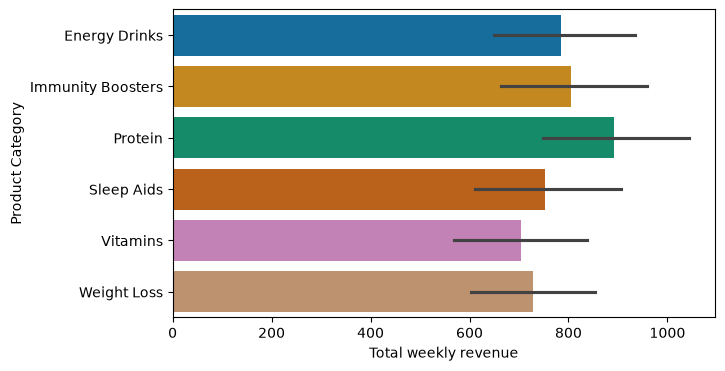

In [276]:
sales_df["week"] = sales_df["date"].dt.to_period("W").apply(lambda x: x.start_time)

# Weekly revenue by product category.  
weekly_category_revenue = sales_df.groupby(["week", "product_category"])["revenue"].sum().reset_index()
# Plotting
plt.figure(figsize=(7, 4))
sns.barplot(weekly_category_revenue, y="product_category", x="revenue", palette="colorblind")
plt.xlabel("Total weekly revenue")
plt.ylabel("Product Category")
plt.show()